TASK 2 - Email Spam Detection with Machine Learning

Objective

The objective of this project is to develop a Natural Language Processing (NLP)-based binary classification model that can accurately distinguish between spam and legitimate (ham) messages.

The project involves text preprocessing, TF-IDF (Term Frequency–Inverse Document Frequency) feature extraction, and training two machine learning classifiers: Multinomial Naive Bayes and Logistic Regression. The performance of both models is evaluated using accuracy, precision, recall, F1-score, and confusion matrix to determine their effectiveness in detecting spam messages.

Importing The Libraries

In [2]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

Download dataset

In [3]:
import urllib.request
import zipfile
import os

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

urllib.request.urlretrieve(url, "sms_spam_collection.zip")

with zipfile.ZipFile("sms_spam_collection.zip", "r") as zip_ref:
    zip_ref.extractall("sms_spam_dataset")

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [4]:
os.listdir("sms_spam_dataset")

['readme', 'SMSSpamCollection']

Load dataset

In [5]:
file_path = "sms_spam_dataset/SMSSpamCollection"

df = pd.read_csv(
    file_path,
    sep="\t",
    header=None,
    names=["label", "message"]
)

Dataset Information

In [6]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.shape

(5572, 2)

In [8]:
df.dtypes

label      object
message    object
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [10]:
df.isna().sum()

label      0
message    0
dtype: int64

Spam vs Ham count

In [12]:
print(df["label"].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


Percentage

In [13]:
print(
    df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


Visualization

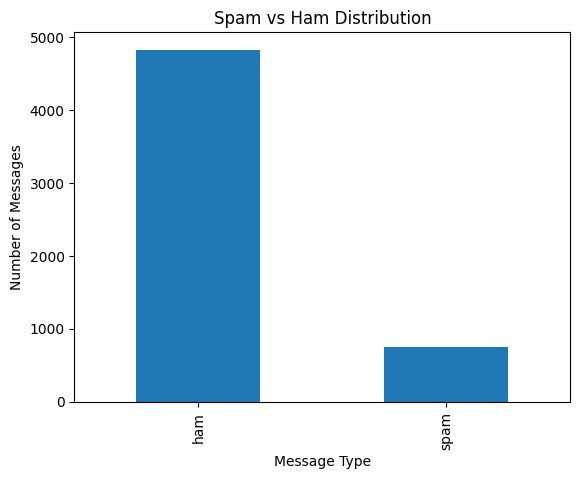

In [14]:
df["label"].value_counts().plot(kind="bar")

plt.title("Spam vs Ham Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.show()


Text preprocessing

In [15]:
import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kusum\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Create preprocessing function

In [16]:
def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Split into words
    words = text.split()

    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    # Join words
    return " ".join(words)

In [17]:
df["clean_message"] = df["message"].apply(preprocess_text)

df[["message", "clean_message"]].head()


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


TF-IDF Vectorization

TF-IDF stands for Term Frequency-Inverse Document Frequency.

TF-IDF converts text into numerical values that machine learning models can understand.

TF (Term Frequency) measures how frequently a word appears in a message.
IDF (Inverse Document Frequency) gives lower importance to words that appear in many messages and higher importance to words that are more unique.
TF-IDF combines TF and IDF to assign an importance score to each word.
In spam detection, TF-IDF helps the model identify important words that can distinguish spam messages from legitimate (ham) messages.

Train/Test Split



In [20]:
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

In [21]:
# Create numerical labels
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# Your existing code
X = df['message']
y = df['label_num']

In [22]:
X = df['clean_message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


Apply TF-IDF

In [23]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)


Training TF-IDF shape: (4457, 5000)
Testing TF-IDF shape: (1115, 5000)


Model 1 — Multinomial Naive Bayes

In [24]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

Evaluation

In [25]:
print("Multinomial Naive Bayes")
print("-----------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall   :", recall_score(y_test, y_pred_nb))
print("F1 Score :", f1_score(y_test, y_pred_nb))

Multinomial Naive Bayes
-----------------------
Accuracy : 0.9695067264573991
Precision: 1.0
Recall   : 0.7718120805369127
F1 Score : 0.8712121212121212


Detailed report

In [26]:
print(classification_report(
    y_test,
    y_pred_nb,
    target_names=['Ham', 'Spam']
))

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



Naive Bayes Confusion Matrix

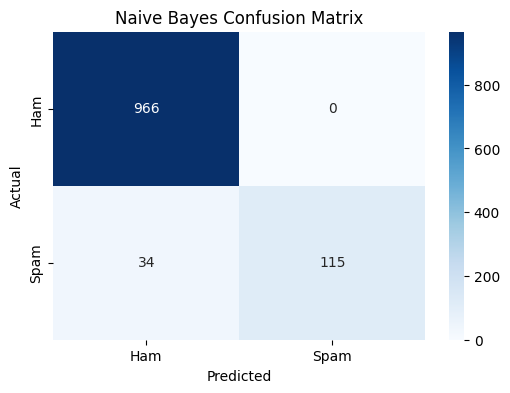

In [27]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Model 2 — Logistic Regression

In [28]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

Evaluation

In [29]:
print("Logistic Regression")
print("-------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Logistic Regression
-------------------
Accuracy : 0.9695067264573991
Precision: 1.0
Recall   : 0.7718120805369127
F1 Score : 0.8712121212121212


Detailed report

In [30]:
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['Ham', 'Spam']
))

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



Logistic Regression Confusion Matrix

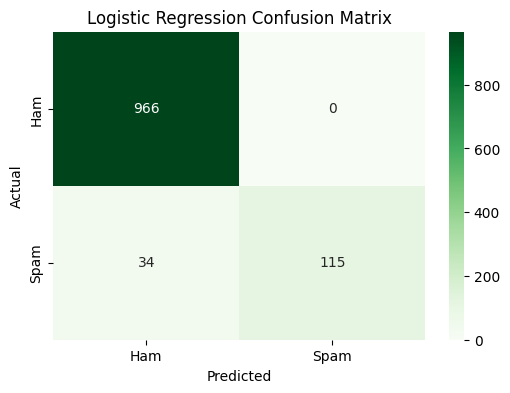

In [31]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Compare both models

In [32]:
results = pd.DataFrame({
    'Model': [
        'Multinomial Naive Bayes',
        'Logistic Regression'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr)
    ],
    'Precision': [
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_lr)
    ],
    'Recall': [
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_lr)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_lr)
    ]
})

results


,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.969507,1.0,0.771812,0.871212
1,Logistic Regression,0.969507,1.0,0.771812,0.871212


Visualization

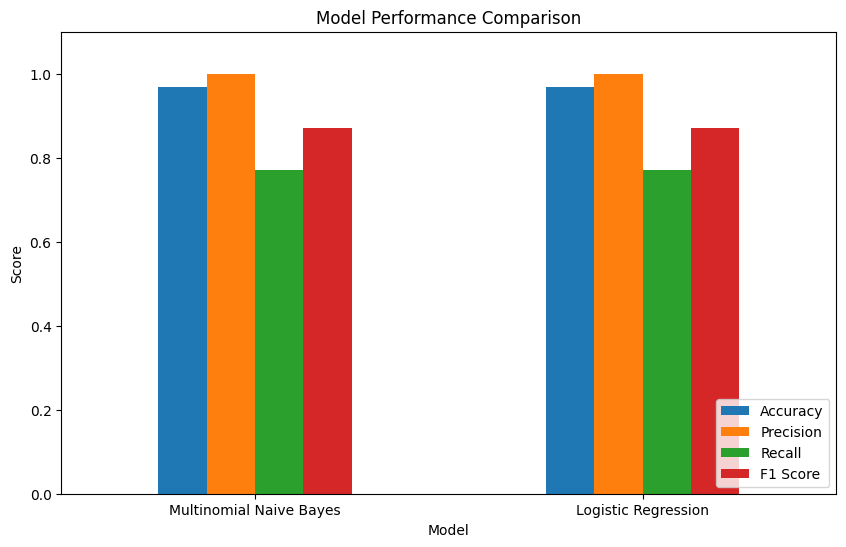

In [33]:
results.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

Why is Recall Important for Spam Detection?

Recall is particularly important in spam detection because it measures how many of the actual spam messages were correctly identified as spam.

Recall = True Positives / (True Positives + False Negatives)

A false negative occurs when a spam message is incorrectly classified as a legitimate (ham) message.

For example, if an email contains a phishing link, fraudulent offer, or malicious content, incorrectly classifying it as ham could be dangerous.

Therefore, a good spam detection system should have high recall so that it can identify as many actual spam messages as possible.

However, precision is also important because incorrectly classifying a legitimate email as spam can cause users to miss important messages.

Bonus — WordCloud

In [34]:
!pip install wordcloud


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
from wordcloud import WordCloud

Spam WordCloud

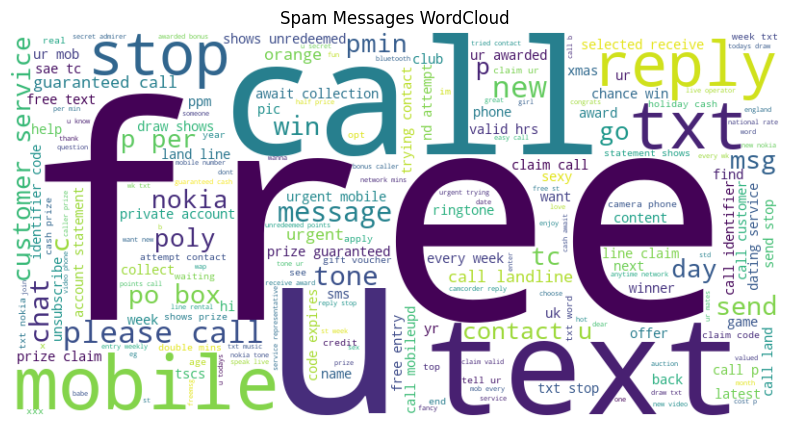

In [37]:
spam_text = ' '.join(
    df[df['label'] == 'spam']['clean_message']
)

spam_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(spam_text)

plt.figure(figsize=(10,5))
plt.imshow(spam_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Spam Messages WordCloud")
plt.show()

Ham WordCloud

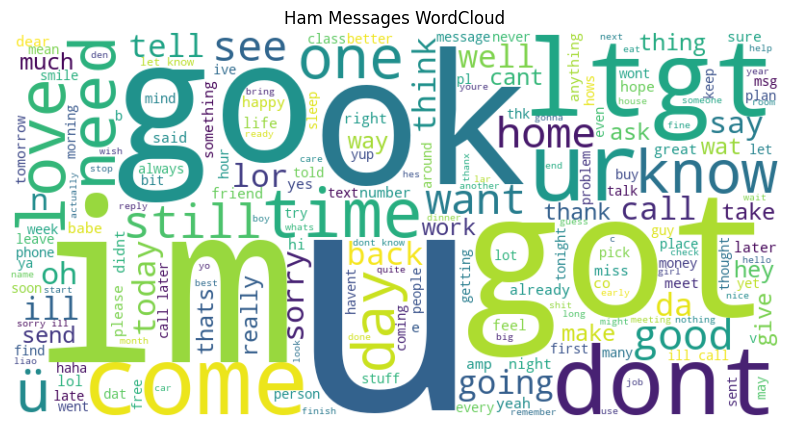

In [38]:
ham_text = ' '.join(
    df[df['label'] == 'ham']['clean_message']
)

ham_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(ham_text)

plt.figure(figsize=(10,5))
plt.imshow(ham_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Ham Messages WordCloud")
plt.show()

Test with your own message

In [39]:
def predict_message(message):
    cleaned = preprocess_text(message)
    vectorized = tfidf.transform([cleaned])
    prediction = lr_model.predict(vectorized)[0]
    
    if prediction == 1:
        return "Spam"
    else:
        return "Ham"